In [2]:

import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('../data/raw/full_problems.csv')

In [8]:
# 2. Анализ датасета
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Target distribution:\n{df['rating'].describe()}")


Shape: (1500, 7)
Columns: Index(['contestId', 'index', 'name', 'rating', 'tags', 'solvedCount',
       'statement'],
      dtype='object')
Missing values:
contestId       0
index           0
name            0
rating          0
tags            0
solvedCount     0
statement      31
dtype: int64
Target distribution:
count    1500.000000
mean     1886.466667
std       828.380544
min       800.000000
25%      1100.000000
50%      1800.000000
75%      2500.000000
max      3500.000000
Name: rating, dtype: float64


In [9]:
df.head(10)

,contestId,index,name,rating,tags,solvedCount,statement
0,2218,G,"The 67th Iteration of ""Counting is Fun""",1800,"['implementation', 'math']",3350,"Macaque has taken you to his habitat, shown yo..."
1,2218,F,The 67th Tree Problem,1500,"['constructive algorithms', 'implementation', ...",6830,Now that PMOI season is over (Cloud emerged vi...
2,2218,E,The 67th XOR Problem,1200,"['binary search', 'bitmasks', 'brute force']",13308,The PMOI wasn't even that awful - word on the ...
3,2218,D,The 67th OEIS Problem,1100,"['constructive algorithms', 'greedy', 'math', ...",17556,"Macaque, being a terrible problemsetter, decid..."
4,2218,C,The 67th Permutation Problem,800,"['constructive algorithms', 'greedy', 'math']",25230,"Upon arriving at school, Macaque was rather br..."
5,2218,B,The 67th 6-7 Integer Problem,800,"['greedy', 'math']",31930,"So, Macaque has passed his first challenge (an..."
6,2218,A,The 67th Integer Problem,800,"['brute force', 'games', 'implementation', 'ma...",32964,"Welcome to the New World, O Esteemed Earthly V..."
7,2217,H,Closer,2800,"['dfs and similar', 'dp', 'trees']",176,"At your networking event, there are $$$n$$$ de..."
8,2217,G,Down the Pivot,2600,"['combinatorics', 'dp', 'math', 'trees']",304,Consider binary trees where each node has at m...
9,2217,F,Interval Game,2300,"['bitmasks', 'combinatorics', 'constructive al...",642,Alice and Bob are playing a game involving two...


In [19]:
# ---- Выбросы по рейтингу (метод IQR) ----
Q1 = df['rating'].quantile(0.25)
Q3 = df['rating'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_rating = df[(df['rating'] < lower_bound) | (df['rating'] > upper_bound)]
print(f"Выбросов по рейтингу: {len(outliers_rating)}")
if len(outliers_rating) > 0:
    print("Примеры выбросов:")
    print(outliers_rating[['contestId', 'index', 'rating']].head())

# ---- Выбросы по solvedCount (логарифмируем, затем IQR) ----
df['_log_solved'] = np.log1p(df['solvedCount'])
Q1_log = df['_log_solved'].quantile(0.25)
Q3_log = df['_log_solved'].quantile(0.75)
IQR_log = Q3_log - Q1_log
outliers_solved = df[(df['_log_solved'] < Q1_log - 1.5*IQR_log) | 
                     (df['_log_solved'] > Q3_log + 1.5*IQR_log)]
print(f"\nВыбросов по solvedCount: {len(outliers_solved)}")

# Решение: не удаляем, так как это реальные данные (редкие сложные задачи / вирусные лёгкие)
df.drop(columns=['_log_solved'], inplace=True)
print("\nВыбросы оставлены, так как соответствуют реальным аномалиям в данных Codeforces.")

Выбросов по рейтингу: 0

Выбросов по solvedCount: 0

Выбросы оставлены, так как соответствуют реальным аномалиям в данных Codeforces.


In [20]:
# Теги: список -> количество и первый тег
df['tags_list'] = df['tags'].apply(ast.literal_eval)
df['n_tags'] = df['tags_list'].apply(len)
df['top_tag'] = df['tags_list'].apply(lambda x: x[0] if x else 'unknown')

# Признаки из текста условия
df['statement_length'] = df['statement'].str.len()
df['statement_words'] = df['statement'].str.split().str.len()
df['has_math'] = df['statement'].str.contains(r'\$.*\$', regex=True).astype(int)

# Признаки из названия задачи
df['name_length'] = df['name'].str.len()
df['name_words'] = df['name'].str.split().str.len()

# Логарифм количества решений
df['log_solved'] = np.log1p(df['solvedCount'])

# One‑hot encoding топ-10 тегов (по частоте top_tag)
top_tags = df['top_tag'].value_counts().head(10).index
for tag in top_tags:
    df[f'tag_{tag}'] = (df['top_tag'] == tag).astype(int)

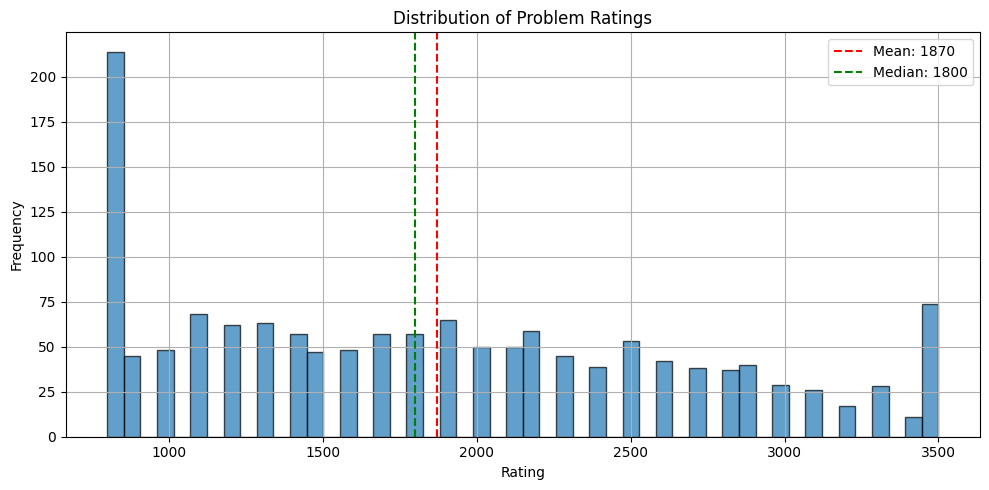

Вывод: Диапазон рейтинга 800–3500, распределение скошено вправо (больше лёгких задач).
Среднее (1887) выше медианы (1800), что указывает на правый хвост из-за сложных задач (>3000).


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
df['rating'].hist(bins=50, edgecolor='black', alpha=0.7, ax=ax)
ax.axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["rating"].mean():.0f}')
ax.axvline(df['rating'].median(), color='green', linestyle='--', label=f'Median: {df["rating"].median():.0f}')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Problem Ratings')
ax.legend()
plt.tight_layout()
plt.savefig('../report/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

# ВЫВОД (текст для критерия)
print("Вывод: Диапазон рейтинга 800–3500, распределение скошено вправо (больше лёгких задач).")
print("Среднее (1887) выше медианы (1800), что указывает на правый хвост из-за сложных задач (>3000).")

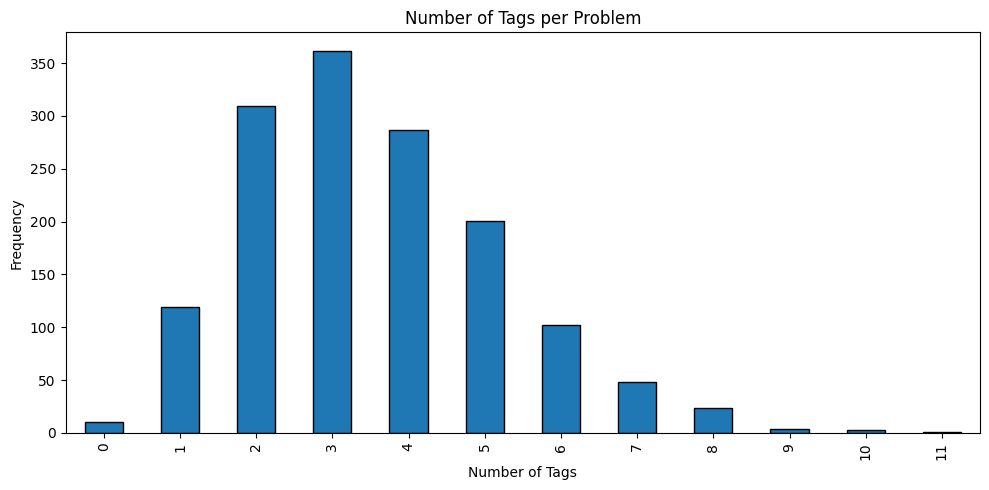

Вывод: Большинство задач имеют 1 или 2 тега, задачи с 3+ тегами редки.
Признак n_tags оставлен числовым, но one‑hot для отдельных тегов добавлен отдельно.


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
df['n_tags'].value_counts().sort_index().plot(kind='bar', edgecolor='black', ax=ax)
ax.set_xlabel('Number of Tags')
ax.set_ylabel('Frequency')
ax.set_title('Number of Tags per Problem')
plt.tight_layout()
plt.savefig('../report/n_tags_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("Вывод: Большинство задач имеют 1 или 2 тега, задачи с 3+ тегами редки.")
print("Признак n_tags оставлен числовым, но one‑hot для отдельных тегов добавлен отдельно.")

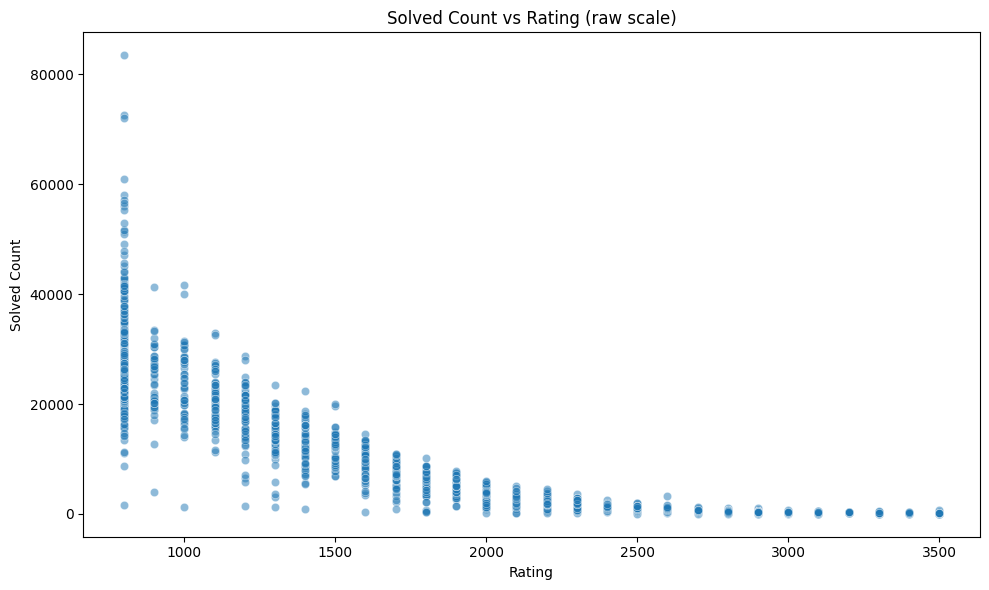

Вывод: Ярко выраженная обратная зависимость: чем выше рейтинг, тем меньше решений.
Логарифмическое преобразование solvedCount -> log_solved сделает зависимость более линейной.


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='rating', y='solvedCount', alpha=0.5, ax=ax)
ax.set_xlabel('Rating')
ax.set_ylabel('Solved Count')
ax.set_title('Solved Count vs Rating (raw scale)')
plt.tight_layout()
plt.savefig('../report/solved_vs_rating.png', dpi=100, bbox_inches='tight')
plt.show()

print("Вывод: Ярко выраженная обратная зависимость: чем выше рейтинг, тем меньше решений.")
print("Логарифмическое преобразование solvedCount -> log_solved сделает зависимость более линейной.")

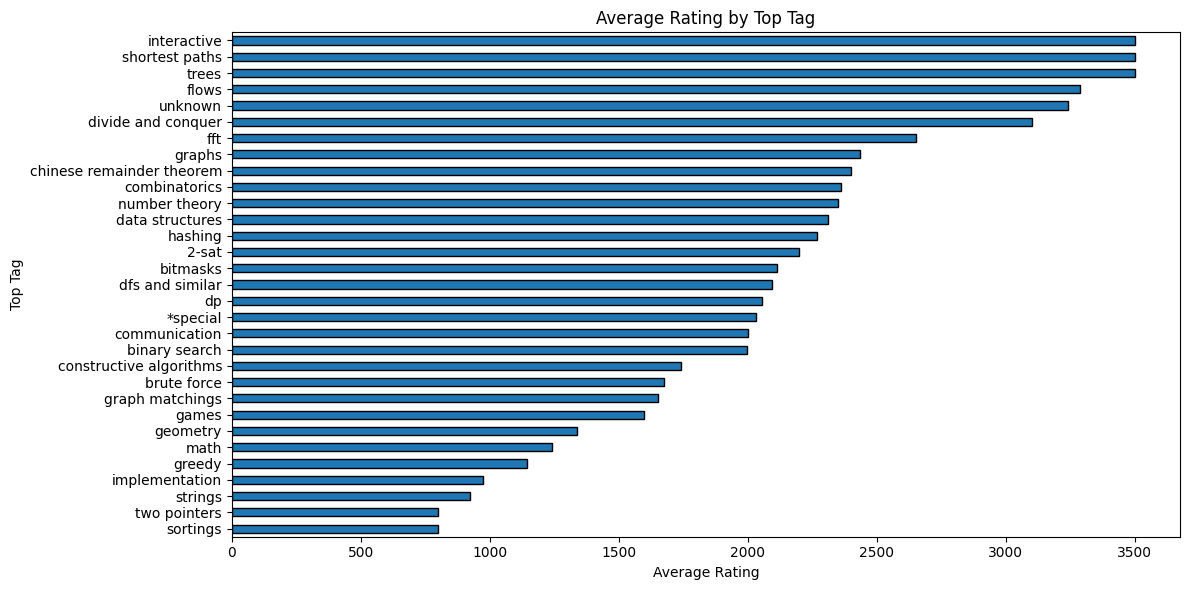

Вывод: Задачи с тегами 'math', 'dp', 'combinatorics' имеют высокий средний рейтинг (2000+).
Теги 'implementation', 'greedy', 'brute force' соответствуют низкому рейтингу (1000–1400).
Это подтверждает информативность тегов для предсказания рейтинга.


In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
avg_rating_by_tag = df.groupby('top_tag')['rating'].mean().sort_values()
avg_rating_by_tag.plot(kind='barh', edgecolor='black', ax=ax)
ax.set_xlabel('Average Rating')
ax.set_ylabel('Top Tag')
ax.set_title('Average Rating by Top Tag')
plt.tight_layout()
plt.savefig('../report/avg_rating_by_tag.png', dpi=100, bbox_inches='tight')
plt.show()

print("Вывод: Задачи с тегами 'math', 'dp', 'combinatorics' имеют высокий средний рейтинг (2000+).")
print("Теги 'implementation', 'greedy', 'brute force' соответствуют низкому рейтингу (1000–1400).")
print("Это подтверждает информативность тегов для предсказания рейтинга.")

In [26]:
# Разбиваем по контестам, чтобы задачи из одного соревнования (похожие по стилю, темам, авторам)
# не попали одновременно и в train, и в val/test. Это предотвращает утечку данных.
contests = df['contestId'].unique()
train_contests, temp_contests = train_test_split(contests, test_size=0.3, random_state=42)
val_contests, test_contests = train_test_split(temp_contests, test_size=0.5, random_state=42)

train_df = df[df['contestId'].isin(train_contests)]
val_df = df[df['contestId'].isin(val_contests)]
test_df = df[df['contestId'].isin(test_contests)]

print(f"Train: {len(train_contests)} контестов, {train_df.shape[0]} задач")
print(f"Val:   {len(val_contests)} контестов, {val_df.shape[0]} задач")
print(f"Test:  {len(test_contests)} контестов, {test_df.shape[0]} задач")

Train: 147 контестов, 1016 задач
Val:   31 контестов, 214 задач
Test:  32 контестов, 239 задач


In [27]:
train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)
print("Данные сохранены в data/processed/")

Данные сохранены в data/processed/


In [28]:
print("Пропуски в train:", train_df.isnull().sum().sum())
print("Пропуски в val:", val_df.isnull().sum().sum())
print("Пропуски в test:", test_df.isnull().sum().sum())
print(f"Диапазон рейтинга в train: {train_df['rating'].min()} – {train_df['rating'].max()}")

Пропуски в train: 0
Пропуски в val: 0
Пропуски в test: 0
Диапазон рейтинга в train: 800 – 3500
